# Heat Hazard Score — # Heat Hazard Score — Porto Alegre

Combines four normalized thermal layers into a single **heat hazard score (H)**,
then aggregates to neighborhood (bairro) level for use in the risk framework
`R = (H × E × V)^(1/3)`.

## Input layers

| Layer | File | Resolution | Script |
|-------|------|-----------|--------|
| Landsat 8 P90 LST norm | `lst_lc08_norm_djf_2015_2024_poa.tif` | 30 m | `lst_landsat8.ipynb` |
| ERA5-Land HW freq norm | `era5_hw_norm_djf_2015_2024_poa.tif` | ~9 km | `era5_land.ipynb` |
| MODIS Day P90 LST norm | `mod11a2_lst_day_norm_djf_2015_2024_poa.tif` | 1 km | `MOD11A2.ipynb` |
| MODIS Night P90 LST norm | `mod11a2_lst_night_norm_djf_2015_2024_poa.tif` | 1 km | `MOD11A2.ipynb` |

## Methodology

### Combination strategy
All layers are already normalized to [0, 1]. The ensemble uses an **arithmetic mean**
of all valid layers per pixel:

```
H_pixel = mean(LST_norm, ERA5_norm, MODIS_day_norm, MODIS_night_norm)
```

Pixels with fewer than 2 valid layers are masked as no-data.

### Resampling
All layers are resampled to a **250 m grid** (consistent with the flood hazard score)
using bilinear interpolation before stacking. Landsat (30 m → 250 m) is downsampled;
ERA5 (~9 km → 250 m) and MODIS (1 km → 250 m) are upsampled.

### Barrio aggregation
The pixel-level ensemble is spatially averaged within each POA bairro
(Censo 2022 boundaries, n = 94) to produce the neighbourhood-level `H` score
used in the risk equation.

## Outputs
| File | Description |
|------|-------------|
| `heat_hazard_score_poa.tif` | Pixel-level ensemble (0–1), 250 m |
| `heat_hazard_n_layers_poa.tif` | Valid layer count per pixel (QA), 250 m |
| `heat_hazard_score_poa.gpkg` | Bairro-level mean hazard score |

Combines four normalized thermal layers into a single **heat hazard score (H)**,
then aggregates to neighborhood (bairro) level for use in the risk framework
`R = (H × E × V)^(1/3)`.

## Input layers

| Layer | File | Resolution | Script |
|-------|------|-----------|--------|
| Landsat 8 P90 LST norm | `lst_lc08_norm_djf_2015_2024_poa.tif` | 30 m | `lst_landsat8.ipynb` |
| ERA5-Land HW freq norm | `era5_hw_norm_djf_2015_2024_poa.tif` | ~9 km | `era5_land.ipynb` |
| MODIS Day P90 LST norm | `mod11a2_lst_day_norm_djf_2015_2024_poa.tif` | 1 km | `MOD11A2.ipynb` |
| MODIS Night P90 LST norm | `mod11a2_lst_night_norm_djf_2015_2024_poa.tif` | 1 km | `MOD11A2.ipynb` |

## Methodology

### Combination strategy
All layers are already normalized to [0, 1]. The ensemble uses an **arithmetic mean**
of all valid layers per pixel:

```
H_pixel = mean(LST_norm, ERA5_norm, MODIS_day_norm, MODIS_night_norm)
```

Pixels with fewer than 2 valid layers are masked as no-data.

### Resampling
All layers are resampled to a **250 m grid** (consistent with the flood hazard score)
using bilinear interpolation before stacking. Landsat (30 m → 250 m) is downsampled;
ERA5 (~9 km → 250 m) and MODIS (1 km → 250 m) are upsampled.

### Barrio aggregation
The pixel-level ensemble is spatially averaged within each POA bairro
(Censo 2022 boundaries, n = 94) to produce the neighbourhood-level `H` score
used in the risk equation.

## Outputs
| File | Description |
|------|-------------|
| `heat_hazard_score_poa.tif` | Pixel-level ensemble (0–1), 250 m |
| `heat_hazard_n_layers_poa.tif` | Valid layer count per pixel (QA), 250 m |
| `heat_hazard_score_poa.gpkg` | Bairro-level mean hazard score |


In [8]:
# Site configuration — transformation/heat_hazard city configs + model defaults
import os
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
_HEAT_HAZARD = None
for _candidate in [_HERE, *_HERE.parents]:
    _probe = _candidate / "heat_hazard" if _candidate.name != "heat_hazard" else _candidate
    if (_probe / "site_config.py").is_file() and (_probe / "config" / "sites").is_dir():
        _HEAT_HAZARD = _probe
        break
if _HEAT_HAZARD is None:
    raise FileNotFoundError("Could not locate transformation/heat_hazard from notebook cwd")

sys.path.insert(0, str(_HEAT_HAZARD))
from site_config import load_site_config

HEAT_HAZARD_ROOT = _HEAT_HAZARD
HEAT_ROOT = HEAT_HAZARD_ROOT  # backward-compatible alias

# Set the city here (edit this line). That value wins for interactive runs.
# Use None to fall back to env HEAT_SITE (default porto_alegre).
SITE_SLUG = "plymouth"  # or: "porto_alegre" | "edina" | "richfield" | "rochester" | "apple_valley" | None
if SITE_SLUG is None:
    SITE_SLUG = os.environ.get("HEAT_SITE", "porto_alegre")
SITE_CONFIG = load_site_config(SITE_SLUG, HEAT_HAZARD_ROOT)
SITE_ROOT = SITE_CONFIG["paths_abs"]["site_root"]
INPUT_DIR = SITE_CONFIG["paths_abs"]["data_input"]
INTERMEDIATE_DIR = SITE_CONFIG["paths_abs"]["data_intermediate"]
OUTPUT_DIR = SITE_CONFIG["paths_abs"]["data_output"]
OUT_ROOT = SITE_CONFIG["paths_abs"]["out"]
CACHE_DIR = SITE_CONFIG["paths_abs"]["cache"]
STYLES_DIR = SITE_CONFIG["paths_abs"]["styles"]
OUTPUT_PREFIX = SITE_CONFIG["output_prefix"]
SEASON = SITE_CONFIG["season"]
SEASON_LABEL = SITE_CONFIG["season_label"]
START_YEAR = int(SITE_CONFIG["start_year"])
END_YEAR = int(SITE_CONFIG["end_year"])
HAZARD_CFG = SITE_CONFIG["hazard"]
PUBLISH_CFG = SITE_CONFIG.get("publish", {})
BAIRRO_CFG = SITE_CONFIG.get("bairro", {})
MODEL_CONFIG_PATH = SITE_CONFIG["model_config_path"]
print(f"Heat hazard site: {SITE_CONFIG['display_name']} ({SITE_SLUG})")
print(f"Config: {SITE_CONFIG['config_path']}")
print(f"Model defaults: {MODEL_CONFIG_PATH}")
print(f"Season: {SEASON_LABEL} {START_YEAR}-{END_YEAR}")
print(f"include_era5={HAZARD_CFG.get('include_era5')} min_layers={HAZARD_CFG.get('min_layers')}")
print(f"Inputs -> {INPUT_DIR}")


Heat hazard site: Plymouth (plymouth)
Config: /Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/config/sites/plymouth.yaml
Model defaults: /Users/admin/Desktop/OEF/geospatial-data/models/heat_hazard/config.yaml
Season: JJA 2015-2024
include_era5=False min_layers=2
Inputs -> /Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/sites/plymouth/data/input


## 0. Setup

In [13]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from rasterio.mask import mask as rio_mask
from rasterio.features import geometry_mask
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
import geemap
import warnings
warnings.filterwarnings('ignore')
import importlib
import heat_hazard_publish
importlib.reload(heat_hazard_publish)

<module 'heat_hazard_publish' from '/Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/heat_hazard_publish.py'>

## 1. Paths & layer definitions

In [10]:
BASE_DIR = HEAT_HAZARD_ROOT
# Normalized input layers live in sites/<site>/data/input/
DATA_DIR = INPUT_DIR

# Optional neighbourhood polygons (POA). Disabled automatically when path missing.
BARRIOS_PATH = BAIRRO_CFG.get("gpkg_path_abs")
POA_MUN_CODE = str(BAIRRO_CFG.get("mun_code", ""))
BAIRRO_LAYER = BAIRRO_CFG.get("layer", "BR_bairros_CD2022")
BAIRRO_ENABLED = bool(BAIRRO_CFG.get("enabled")) and BARRIOS_PATH is not None and Path(BARRIOS_PATH).exists()
if BAIRRO_CFG.get("enabled") and not BAIRRO_ENABLED:
    print("Bairro aggregation configured but gpkg missing — set HEAT_BAIRRO_GPKG or bairro.gpkg_path")

# Layers: (label, filename, weight, resampling)
# ERA5 is excluded by default for city-scale hazard because its native grid is coarse.
_weights = HAZARD_CFG.get("layer_weights", {})
LAYERS = [
    ('Landsat LST', SITE_CONFIG['layers']['landsat_norm'], float(_weights.get('landsat_norm', 1.0)), Resampling.bilinear),
    ('MODIS LST Day', SITE_CONFIG['layers']['modis_day_norm'], float(_weights.get('modis_day_norm', 1.0)), Resampling.nearest),
    ('MODIS LST Night', SITE_CONFIG['layers']['modis_night_norm'], float(_weights.get('modis_night_norm', 1.0)), Resampling.nearest),
]
if HAZARD_CFG.get('include_era5', False):
    LAYERS.append(('ERA5 HW Frequency', SITE_CONFIG['layers']['era5_hw_norm'], float(_weights.get('era5_hw_norm', 1.0)), Resampling.nearest))

MIN_VALID_LAYERS = int(HAZARD_CFG.get('min_layers', 2))

print('Input layers:')
for label, fname, w, _ in LAYERS:
    p = DATA_DIR / fname
    status = 'OK' if p.exists() else 'MISSING'
    size = f'{p.stat().st_size / 1024:.1f} KB' if p.exists() else 'not found'
    print(f'  [{status:7s}]  {label:<22}  {fname}  ({size})')


Input layers:
  [OK     ]  Landsat LST             lst_lc08_norm_jja_2015_2024_plymouth.tif  (522.7 KB)
  [OK     ]  MODIS LST Day           mod11a2_lst_day_norm_jja_2015_2024_plymouth.tif  (1.8 KB)
  [OK     ]  MODIS LST Night         mod11a2_lst_night_norm_jja_2015_2024_plymouth.tif  (1.8 KB)


## 2. Inspect layers

Check CRS, bounds, resolution, and value range for each input.

In [5]:
print(f"{'Layer':<22} {'Shape':>14} {'Res (m)':>10} {'NoData':>10} {'Min':>7} {'Mean':>7} {'Max':>7}")
print('-' * 82)
for label, fname, _, _ in LAYERS:
    with rasterio.open(DATA_DIR / fname) as src:
        res_m     = src.res[0] * 111_320
        shape_str = f'{src.height}\u00d7{src.width}'
        nodata    = src.nodata

        # Read raw (no masked API) to avoid issues with Float64 + missing nodata tag.
        # Build valid mask manually: exclude NaN, Inf, and the nodata value if set.
        raw   = src.read(1).astype(np.float64)
        valid = np.isfinite(raw)
        if nodata is not None:
            valid &= (raw != nodata)

        if valid.any():
            vmin  = float(raw[valid].min())
            vmean = float(raw[valid].mean())
            vmax  = float(raw[valid].max())
        else:
            vmin = vmean = vmax = float('nan')

        print(f'{label:<22} {shape_str:>14} {res_m:>10.0f} {str(nodata):>10} {vmin:>7.3f} {vmean:>7.3f} {vmax:>7.3f}')

Layer                           Shape    Res (m)     NoData     Min    Mean     Max
----------------------------------------------------------------------------------
Landsat LST                   328×454         30        0.0  -0.005   0.415   1.179
MODIS LST Day                   11×14       1000        0.0   0.038   0.511   1.000
MODIS LST Night                 11×14       1000        0.0   0.017   0.578   1.000


## 3. Resample all layers to a common 250 m grid

All four layers are resampled to a **250 m grid** over the POA bounding box
(consistent with the flood hazard score grid) using **bilinear interpolation**.
This produces a stack of four 2-D arrays aligned on the same pixel grid
regardless of each layer's native resolution.

In [6]:
# ── Build a 250 m reference grid over the site bounding box ─────────────────
# 250 m in degrees at the equator ≈ 0.002245°; consistent with flood hazard grid.
import math
from rasterio.transform import from_origin

TARGET_RES_M  = int(HAZARD_CFG.get('target_resolution_m', 250))
DEG_PER_METRE = 1 / 111_320          # at equator
TARGET_RES_DEG = TARGET_RES_M * DEG_PER_METRE

# Site bounding box from config: [lon_min, lat_min, lon_max, lat_max]
LON_MIN, LAT_MIN, LON_MAX, LAT_MAX = SITE_CONFIG['bbox']

ref_crs    = rasterio.CRS.from_epsg(4326)
ref_width  = math.ceil((LON_MAX - LON_MIN) / TARGET_RES_DEG)
ref_height = math.ceil((LAT_MAX - LAT_MIN) / TARGET_RES_DEG)

# from_origin: upper-left corner, pixel width, pixel height (positive)
ref_transform = from_origin(LON_MIN, LAT_MAX, TARGET_RES_DEG, TARGET_RES_DEG)

print(f'Site           : {SITE_CONFIG["display_name"]} ({SITE_SLUG})')
print(f'BBox           : [{LON_MIN}, {LAT_MIN}, {LON_MAX}, {LAT_MAX}]')
print(f'Target grid    : {ref_height} rows x {ref_width} cols')
print(f'Resolution     : {TARGET_RES_M} m ({TARGET_RES_DEG:.6f}°)')
print(f'CRS            : EPSG:4326')
print(f'Transform      : {ref_transform}')


def resample_to_ref(src_path: Path,
                     method: Resampling = Resampling.nearest) -> np.ma.MaskedArray:
    """
    Reproject + resample a raster to the 250 m reference grid.

    method:
        Resampling.bilinear  -> for downsampling (Landsat 30m -> 250m)
        Resampling.nearest   -> for upsampling (MODIS 1km / ERA5 9km -> 250m);
                                repeats original pixel values, invents nothing.

    GEE exports Float64 without a nodata tag; NaN pixels represent no-data.
    Values slightly outside [0, 1] (e.g. -0.04 or 1.26) from GEE rounding
    are clipped rather than masked.
    """
    dest_nodata = -9999.0
    with rasterio.open(src_path) as src:
        src_nodata = src.nodata
        dest = np.empty((ref_height, ref_width), dtype=np.float64)
        reproject(
            source=rasterio.band(src, 1),
            destination=dest,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src_nodata,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            dst_nodata=dest_nodata,
            resampling=method,
        )
    invalid = (dest == dest_nodata) | ~np.isfinite(dest)
    dest = np.clip(dest, 0.0, 1.0)
    return np.ma.array(dest.astype(np.float32), mask=invalid)


# Resample all layers
arrays = []
for label, fname, _, method in LAYERS:
    arr = resample_to_ref(DATA_DIR / fname, method=method)
    arrays.append(arr)
    mask_arr  = np.ma.getmaskarray(arr)
    valid_pct = (1 - mask_arr.mean()) * 100
    print(f'  {label:<22}  valid: {valid_pct:.1f}%  '
          f'min={float(arr.min()):.3f}  mean={float(arr.mean()):.3f}  max={float(arr.max()):.3f}')

stack = np.ma.stack(arrays, axis=0)   # shape: (n_layers, H, W)
print(f'\nStack shape: {stack.shape}')


Site           : Plymouth (plymouth)
BBox           : [-93.522652, 44.978282, -93.400372, 45.066422]
Target grid    : 40 rows x 55 cols
Resolution     : 250 m (0.002246°)
CRS            : EPSG:4326
Transform      : | 0.00, 0.00,-93.52|
| 0.00,-0.00, 45.07|
| 0.00, 0.00, 1.00|
  Landsat LST             valid: 95.0%  min=0.003  mean=0.414  max=0.898
  MODIS LST Day           valid: 96.8%  min=0.038  mean=0.514  max=1.000
  MODIS LST Night         valid: 96.8%  min=0.017  mean=0.583  max=1.000

Stack shape: (3, 40, 55)


## 4. Ensemble: arithmetic mean

Compute the weighted mean across valid layers per pixel.  
Pixels with fewer than `MIN_VALID_LAYERS` are masked as no-data.

In [7]:
weights = np.array([w for _, _, w, _ in LAYERS], dtype=np.float32)

# Count valid layers per pixel
valid_count = (~stack.mask).sum(axis=0).astype(np.float32)   # shape: (H, W)

# Weighted sum (ignore masked values)
w_sum   = np.zeros((ref_height, ref_width), dtype=np.float32)
w_total = np.zeros((ref_height, ref_width), dtype=np.float32)
for i, (_, _, w, _method) in enumerate(LAYERS):
    valid = ~np.ma.getmaskarray(stack[i])
    w_sum[valid]   += stack[i].data[valid] * w
    w_total[valid] += w

# Avoid divide-by-zero
with np.errstate(invalid='ignore', divide='ignore'):
    ensemble = np.where(w_total > 0, w_sum / w_total, np.nan)

# Mask pixels with insufficient layer coverage
insufficient = valid_count < MIN_VALID_LAYERS
ensemble = np.ma.array(ensemble, mask=insufficient | ~np.isfinite(ensemble))

print('Ensemble heat hazard score:')
print(f'  Valid pixels  : {ensemble.count():,} / {ensemble.size:,}  ({ensemble.count()/ensemble.size*100:.1f}%)')
print(f'  Min           : {float(ensemble.min()):.4f}')
print(f'  Mean          : {float(ensemble.mean()):.4f}')
print(f'  Max           : {float(ensemble.max()):.4f}')
print()
print('Valid layer count distribution:')
for n in range(len(LAYERS) + 1):
    cnt = (valid_count == n).sum()
    print(f'  {n} layers: {cnt:,} pixels ({cnt/valid_count.size*100:.1f}%)')

Ensemble heat hazard score:
  Valid pixels  : 2,145 / 2,200  (97.5%)
  Min           : 0.1101
  Mean          : 0.5043
  Max           : 0.9182

Valid layer count distribution:
  0 layers: 55 pixels (2.5%)
  1 layers: 0 pixels (0.0%)
  2 layers: 87 pixels (4.0%)
  3 layers: 2,058 pixels (93.5%)


## 5. Visualize — input layers + ensemble

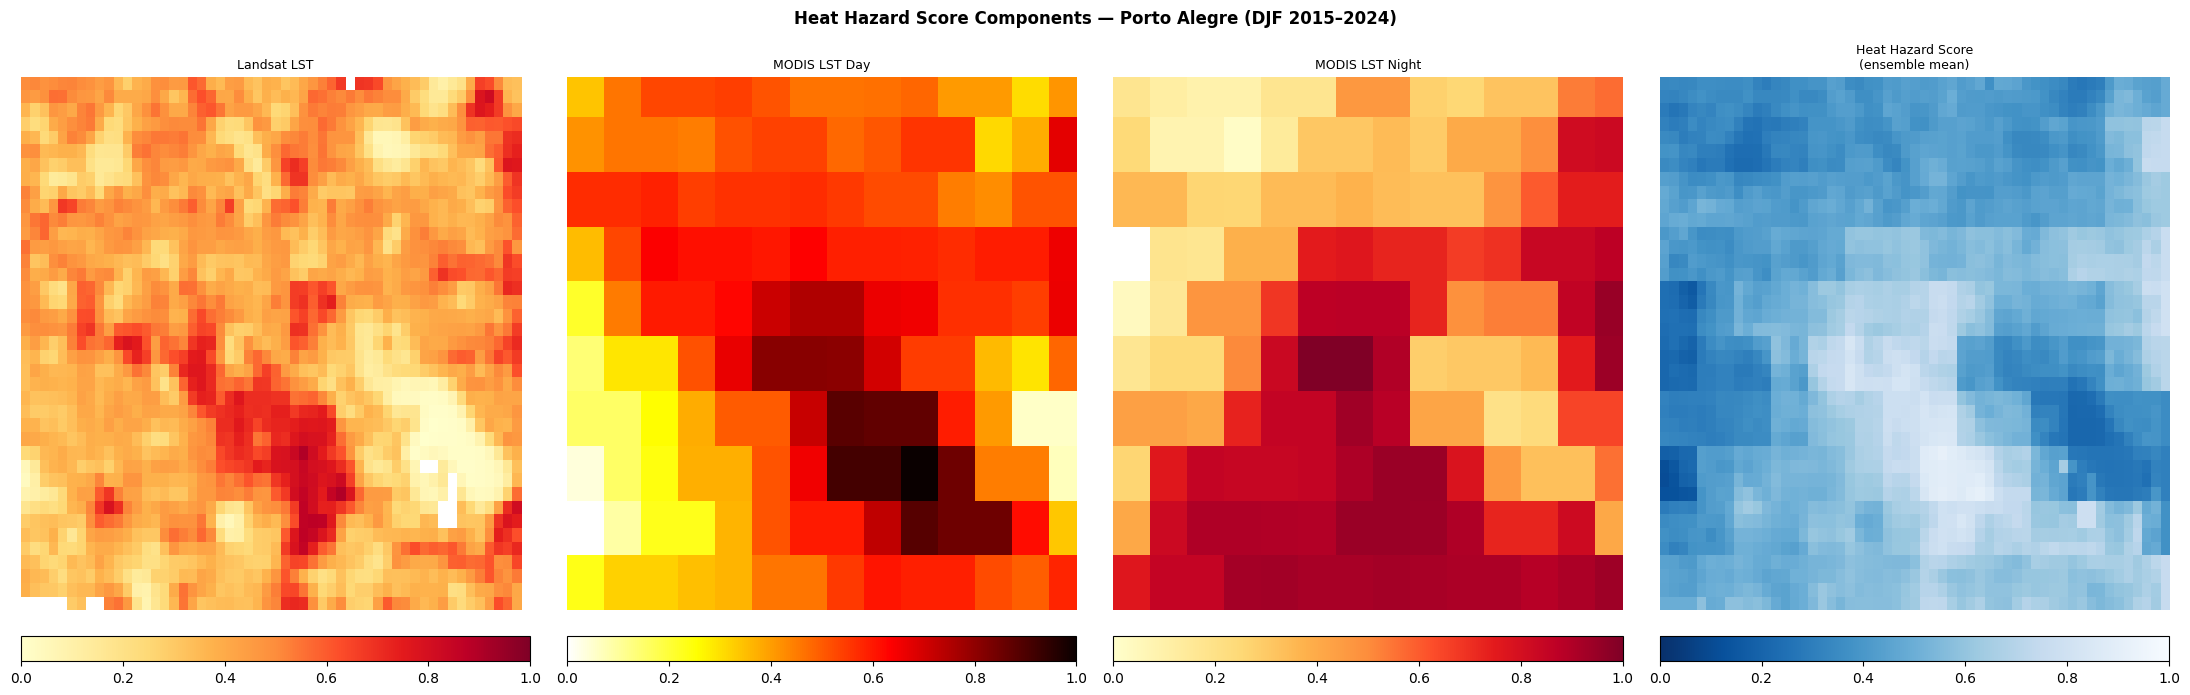

In [8]:
labels = [l for l, _, _, _ in LAYERS]
all_data = list(arrays) + [ensemble]
all_titles = labels + ['Heat Hazard Score\n(ensemble mean)']

fig, axes = plt.subplots(1, 4, figsize=(22, 7))

cmaps  = ['YlOrRd', 'hot_r', 'YlOrRd', 'Blues_r', 'RdYlGn_r']

for i, (ax, data, title, cmap) in enumerate(zip(axes, all_data, all_titles, cmaps)):
    im = ax.imshow(
        data,
        cmap=cmap, vmin=0, vmax=1,
        interpolation='none',
        aspect='auto',
    )
    ax.set_title(title, fontsize=9, fontweight='bold' if i == 4 else 'normal')
    ax.axis('off')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.02, fraction=0.046)

fig.suptitle(
    'Heat Hazard Score Components — Porto Alegre (DJF 2015–2024)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 6. Aggregate to bairros

For each of the 94 POA bairros, compute the **mean ensemble score** across all
valid pixels inside the polygon.  
This is the neighbourhood-level `H` score used in `R = (H × E × V)^(1/3)`.

In [22]:
# ── Load POA bairros ──────────────────────────────────────────────────────────
if not BAIRRO_ENABLED:
    raise RuntimeError('Bairro aggregation disabled or gpkg missing; set HEAT_BAIRRO_GPKG to run this cell')
gdf = gpd.read_file(BARRIOS_PATH, layer=BAIRRO_LAYER)
poa = gdf[gdf['CD_MUN'] == POA_MUN_CODE].copy()
poa = poa.to_crs('EPSG:4326')
print(f'Loaded {len(poa)} bairros for Porto Alegre (CD_MUN = {POA_MUN_CODE})')

# ── Zonal statistics (mean per bairro) ───────────────────────────────────────
# Build a profile matching the reference grid (needed to write temp raster)
profile = {
    'driver': 'GTiff', 'dtype': 'float32', 'width': ref_width,
    'height': ref_height, 'count': 1, 'crs': ref_crs,
    'transform': ref_transform, 'nodata': -9999.0,
}

# Fill nodata for masking
ensemble_filled = ensemble.filled(-9999.0)

scores = []
for _, row in poa.iterrows():
    geom = [row.geometry.__geo_interface__]

    # Create a boolean mask for the bairro polygon
    bmask = geometry_mask(
        geom,
        transform=ref_transform,
        invert=True,       # True = inside the polygon
        out_shape=(ref_height, ref_width),
    )

    # Apply both the bairro mask and the ensemble valid mask
    combined = bmask & (~ensemble.mask)
    if combined.sum() > 0:
        mean_score = float(ensemble_filled[combined].mean())
    else:
        mean_score = float('nan')

    scores.append(mean_score)

poa['heat_hazard_score'] = scores

valid_bairros = poa['heat_hazard_score'].notna().sum()
print(f'\nBairros with valid score : {valid_bairros} / {len(poa)}')
print(f'Score range              : {poa["heat_hazard_score"].min():.4f} – {poa["heat_hazard_score"].max():.4f}')
print(f'Score mean               : {poa["heat_hazard_score"].mean():.4f}')


Loaded 99 bairros for Porto Alegre (CD_MUN = 4314902)

Bairros with valid score : 98 / 99
Score range              : 0.2654 – 0.7507
Score mean               : 0.5642


## 7. Summary statistics — all layers at bairro level

In [23]:
# Aggregate each individual layer to bairro level for comparison
layer_names = [l for l, _, _, _ in LAYERS]
for arr, name in zip(arrays, layer_names):
    col = f'h_{name.lower().replace(" ","_")}'
    col_scores = []
    arr_filled = arr.filled(np.nan)
    for _, row in poa.iterrows():
        bmask = geometry_mask(
            [row.geometry.__geo_interface__],
            transform=ref_transform, invert=True,
            out_shape=(ref_height, ref_width),
        )
        combined = bmask & (~arr.mask)
        col_scores.append(float(arr_filled[combined].mean()) if combined.sum() > 0 else float('nan'))
    poa[col] = col_scores

# Print summary
score_cols = [f'h_{n.lower().replace(" ","_")}' for n in layer_names] + ['heat_hazard_score']
display_labels = layer_names + ['ENSEMBLE']

print(f"{'Layer':<25} {'Min':>7} {'Mean':>7} {'Max':>7} {'Std':>7}")
print('-' * 58)
for col, label in zip(score_cols, display_labels):
    s = poa[col].dropna()
    print(f"{label:<25} {s.min():>7.4f} {s.mean():>7.4f} {s.max():>7.4f} {s.std():>7.4f}")

Layer                         Min    Mean     Max     Std
----------------------------------------------------------
Landsat LST                0.0821  0.5453  0.7708  0.1560
MODIS LST Day              0.0246  0.5974  0.9208  0.2280
MODIS LST Night            0.1970  0.5478  0.7141  0.1450
ENSEMBLE                   0.2654  0.5642  0.7507  0.1480


## 8. Interactive map

Pixel-level heat hazard score on a basemap, with bairro boundaries as vector overlay.
Toggle layers using the layer control (top right).

In [25]:
# ── Helper: save a masked array as a temp TIF ────────────────────────────────
def _save_tmp(arr, name):
    path = OUTPUT_DIR / f'_display_{name}.tif'
    _profile = {
        'driver': 'GTiff', 'dtype': 'float32',
        'width': ref_width, 'height': ref_height,
        'count': 1, 'crs': ref_crs,
        'transform': ref_transform,
        'nodata': -9999.0, 'compress': 'lzw',
    }
    with rasterio.open(path, 'w', **_profile) as dst:
        dst.write(np.ma.filled(arr, -9999.0).astype(np.float32), 1)
    return str(path)


# ── Save all layers + ensemble ────────────────────────────────────────────────
layer_files = [
    (_save_tmp(arrays[0], 'landsat'),     '1. Landsat LST norm (0-1)',     False),
    (_save_tmp(arrays[1], 'modis_day'),   '2. MODIS LST Day norm (0-1)',   False),
    (_save_tmp(arrays[2], 'modis_night'), '3. MODIS LST Night norm (0-1)', False),
    (_save_tmp(ensemble,  'ensemble'),    '4. Heat Hazard Score (0-1)',     True),
]

vis_norm_layers = {
    'min': 0, 'max': 1,
    'palette': ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c'],
}

# ── Map ───────────────────────────────────────────────────────────────────────
m = geemap.Map(center=[-30.10, -51.16], zoom=11)
m.add_basemap('OpenStreetMap.Mapnik')

for tif_path, layer_name, visible in layer_files:
    m.add_raster(
        tif_path,
        colormap='rdylgn_r',
        vmin=0, vmax=1,
        layer_name=layer_name,
        nodata=-9999.0,
        visible=visible,
    )

m.add_gdf(
    poa,
    layer_name='Bairros',
    style={'color': 'white', 'weight': 0.8, 'fillOpacity': 0},
)
# m.add_colorbar(
#     vis_params=vis_norm_layers,
#     label='Normalized score (0–1)',
#     orientation='horizontal',
#     position='bottomright',
#     transparent_bg=True,
# )
m.add_layer_control()
m

Map(center=[-30.1, -51.16], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

## 9. Static map — bairro choropleth

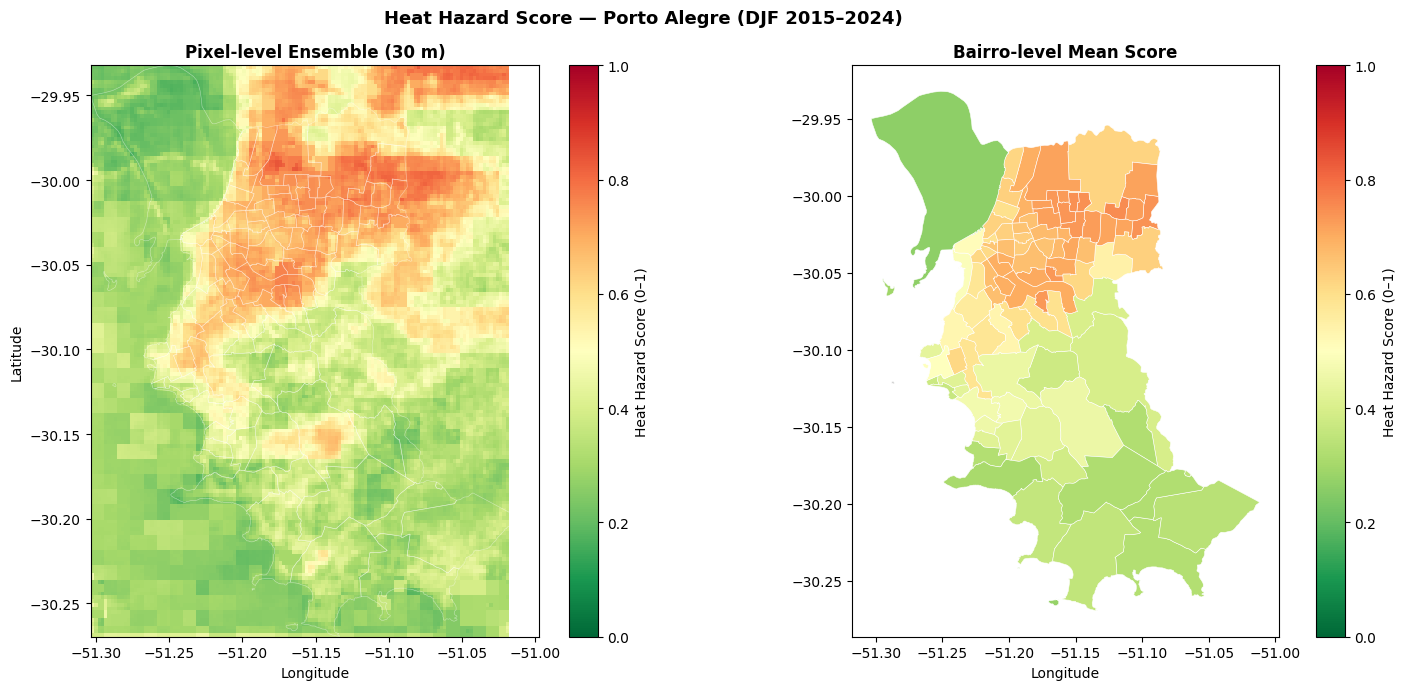

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: pixel-level ensemble ───────────────────────────────────────────────
with rasterio.open(DATA_DIR / LAYERS[0][1]) as src:
    bounds = src.bounds

axes[0].imshow(
    ensemble,
    cmap='RdYlGn_r', vmin=0, vmax=1,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    interpolation='none', aspect='auto',
)
poa.boundary.plot(ax=axes[0], linewidth=0.4, color='white', alpha=0.5)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=mcolors.Normalize(0, 1))
plt.colorbar(sm, ax=axes[0], label='Heat Hazard Score (0–1)', fraction=0.046, pad=0.04)
axes[0].set_title('Pixel-level Ensemble (30 m)', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# ── Right: bairro choropleth ─────────────────────────────────────────────────
poa.plot(
    column='heat_hazard_score',
    ax=axes[1],
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    edgecolor='white', linewidth=0.4,
    legend=True,
    legend_kwds={'label': 'Heat Hazard Score (0–1)', 'orientation': 'vertical'},
    missing_kwds={'color': 'lightgrey'},
)
axes[1].set_title('Bairro-level Mean Score', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('')

fig.suptitle(
    'Heat Hazard Score — Porto Alegre (DJF 2015–2024)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### Top / bottom bairros

In [27]:
ranked = poa[['NM_BAIRRO', 'heat_hazard_score']].dropna().sort_values(
    'heat_hazard_score', ascending=False
).reset_index(drop=True)
ranked.index += 1

print('Top 10 highest heat hazard:')
print(ranked.head(10).to_string())
print()
print('Top 10 lowest heat hazard:')
print(ranked.tail(10).to_string())

Top 10 highest heat hazard:
           NM_BAIRRO  heat_hazard_score
1      Costa e Silva           0.750700
2     Jardim Lindóia           0.742588
3      São Sebastião           0.742287
4        Rubem Berta           0.738958
5    Cristo Redentor           0.737836
6    Jardim do Salso           0.734260
7   Vila João Pessoa           0.734168
8   Jardim São Pedro           0.732427
9      Vila Ipiranga           0.731501
10   Jardim Floresta           0.729114

Top 10 lowest heat hazard:
           NM_BAIRRO  heat_hazard_score
89          Serraria           0.327498
90              Lami           0.327477
91       São Caetano           0.322661
92           Pitinga           0.321532
93           Lageado           0.319746
94      Ponta Grossa           0.306511
95       Arquipélago           0.290807
96  Boa Vista do Sul           0.275304
97        Belém Novo           0.275225
98       Arquipélago           0.265371


## 10. Export

| File | Content |
|------|---------|
| `heat_hazard_score_poa.tif` | Pixel-level ensemble (0–1), 30 m, EPSG:4326 |
| `heat_hazard_n_layers_poa.tif` | Valid layer count per pixel (QA) |
| `heat_hazard_score_poa.gpkg` | Bairro-level scores + per-layer breakdown |

In [9]:
write_profile = {
    'driver':    'GTiff',
    'dtype':     'float32',
    'width':     ref_width,
    'height':    ref_height,
    'count':     1,
    'crs':       ref_crs,
    'transform': ref_transform,
    'nodata':    -9999.0,
    'compress':  'lzw',
}

# ── Ensemble raster ───────────────────────────────────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
out_score = OUTPUT_DIR / SITE_CONFIG['outputs']['heat_hazard_score']
with rasterio.open(out_score, 'w', **write_profile) as dst:
    dst.write(ensemble.filled(-9999.0).astype(np.float32), 1)
print(f'Saved: {out_score.name}')

# ── Valid layer count (QA) ────────────────────────────────────────────────────
out_nlay = OUTPUT_DIR / SITE_CONFIG['outputs']['heat_hazard_n_layers']
qa_profile = {**write_profile, 'dtype': 'uint8', 'nodata': 255}
with rasterio.open(out_nlay, 'w', **qa_profile) as dst:
    dst.write(valid_count.astype(np.uint8), 1)
print(f'Saved: {out_nlay.name}')

# ── Bairro GeoPackage ─────────────────────────────────────────────────────────
if BAIRRO_ENABLED and 'poa' in globals():
    out_gpkg = OUTPUT_DIR / SITE_CONFIG['outputs']['heat_hazard_vector']
    export_cols = ['CD_BAIRRO', 'NM_BAIRRO', 'heat_hazard_score'] + \
                  [c for c in poa.columns if c.startswith('h_')] + \
                  ['geometry']
    poa[export_cols].to_file(out_gpkg, driver='GPKG', layer='heat_hazard_poa')
    print(f'Saved: {out_gpkg.name}')
else:
    print('Skipped bairro GeoPackage export (bairro aggregation not available)')

print('\nAll exports complete.')


Saved: heat_hazard_score_plymouth.tif
Saved: heat_hazard_n_layers_plymouth.tif
Skipped bairro GeoPackage export (bairro aggregation not available)

All exports complete.


## 9. COG + Web Tiles

Publishes `heat_hazard_score_poa.tif` for web maps:
- **COG** (Cloud Optimized GeoTIFF) — float32 0-1, DEFLATE compressed
- **tiles_visual** — colorized XYZ PNG tiles (zoom 8-15) using `heat_hazard_colors.txt`
- **tiles_values** — value-encoded RGB tiles for hover lookup

Decode formula in app: `score = (R + 256×G + 65536×B) / 10000`

Requires GDAL CLI (`gdal_translate`, `gdaldem`, `gdal_calc.py`, `gdal2tiles.py`).

In [11]:
from pathlib import Path
import os
import subprocess
import shutil

HEAT_ROOT  = OUTPUT_DIR
in_tif     = OUTPUT_DIR / SITE_CONFIG['outputs']['heat_hazard_score']
colors_txt = STYLES_DIR / 'heat_hazard_colors.txt'
out_dir    = OUT_ROOT / 'heat_hazard_score'

cog_tif          = out_dir / 'heat_hazard_score_cog.tif'
colorized_tif    = out_dir / 'heat_hazard_score_colorized.tif'
value_encoded_tif = out_dir / 'heat_hazard_score_value_encoded_rgb.tif'
tiles_dir        = out_dir / 'tiles_visual'
value_tiles_dir  = out_dir / 'tiles_values'

out_dir.mkdir(parents=True, exist_ok=True)

if not in_tif.exists():
    raise FileNotFoundError(f'Missing input raster: {in_tif}')
if not colors_txt.exists():
    raise FileNotFoundError(f'Missing color table: {colors_txt}')

# Jupyter kernels often lack Homebrew on PATH.
GDAL_CANDIDATE_DIRS = [
    Path('/opt/homebrew/bin'),
    Path('/usr/local/bin'),
    Path(os.environ.get('HOME', '')) / 'homebrew' / 'bin',
]


def resolve_gdal_tool(name: str) -> str:
    found = shutil.which(name)
    if found:
        return found
    for directory in GDAL_CANDIDATE_DIRS:
        candidate = directory / name
        if candidate.is_file() and os.access(candidate, os.X_OK):
            return str(candidate)
    raise FileNotFoundError(
        f"Could not find `{name}`. Install GDAL (e.g. `brew install gdal`) "
        f"or add it to PATH. Checked: PATH plus {', '.join(str(p) for p in GDAL_CANDIDATE_DIRS)}"
    )


GDAL_TRANSLATE = resolve_gdal_tool('gdal_translate')
GDALDEM = resolve_gdal_tool('gdaldem')
GDAL2TILES = resolve_gdal_tool('gdal2tiles.py')
GDAL_CALC = resolve_gdal_tool('gdal_calc.py')

print('Input   :', in_tif)
print('Out dir :', out_dir)
print('GDAL    :', GDAL_TRANSLATE)


Input   : /Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/sites/plymouth/data/output/heat_hazard_score_plymouth.tif
Out dir : /Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/sites/plymouth/out/heat_hazard_score
GDAL    : /opt/homebrew/bin/gdal_translate


In [11]:
# ── 1. COG (float32, DEFLATE) ─────────────────────────────────────────────────
subprocess.run([
    GDAL_TRANSLATE, str(in_tif), str(cog_tif),
    '-of', 'COG',
    '-ot', 'Float32',
    '-co', 'COMPRESS=DEFLATE',
    '-co', 'RESAMPLING=NEAREST',
    '-co', 'OVERVIEWS=AUTO',
], check=True)
print('COG :', cog_tif)

# ── 2. Colorized raster (for visual tiles) ────────────────────────────────────
subprocess.run([
    GDALDEM, 'color-relief', str(cog_tif), str(colors_txt), str(colorized_tif),
    '-alpha',
], check=True)
print('Colorized:', colorized_tif)

# ── 3. Visual XYZ tiles (zoom 8-15) ──────────────────────────────────────────
gdal2tiles_python = None
with open(GDAL2TILES, 'r', encoding='utf-8', errors='ignore') as f:
    first_line = f.readline().strip()
if first_line.startswith('#!'):
    shebang_parts = first_line[2:].split()
    if shebang_parts:
        if shebang_parts[0].endswith('env') and len(shebang_parts) > 1:
            gdal2tiles_python = shutil.which(shebang_parts[1])
        else:
            gdal2tiles_python = shebang_parts[0]
if not gdal2tiles_python:
    gdal2tiles_python = shutil.which('python3') or shutil.which('python')
subprocess.run([gdal2tiles_python, '-c', 'import numpy'], check=True, capture_output=True)

tiles_dir.mkdir(parents=True, exist_ok=True)
subprocess.run([
    GDAL2TILES,
    '-r', 'near',
    '-z', str(PUBLISH_CFG.get('tile_zoom', '8-15')),
    '--xyz',
    '-w', 'none',
    str(colorized_tif),
    str(tiles_dir),
], check=True)
print('Visual tiles:', tiles_dir)


Input file size is 55, 40
0...10...20...30...40...50...60...70...80...90...100 - done.
COG : /Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/sites/plymouth/out/heat_hazard_score/heat_hazard_score_cog.tif
0...10...20...30...40...50...60...70...80...90...100 - done.
Colorized: /Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/sites/plymouth/out/heat_hazard_score/heat_hazard_score_colorized.tif


Generating Base Tiles:


0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...

Generating Overview Tiles:


60...70...80...90...100 - done.
Visual tiles: /Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/sites/plymouth/out/heat_hazard_score/tiles_visual


In [12]:
# ── 4. Value-encoded RGB tiles (hover lookup) ─────────────────────────────────
# Encode score as integer in [0, 10000] packed across 3 bytes:
#   R = value & 0xFF
#   G = (value >> 8) & 0xFF
#   B = (value >> 16) & 0xFF
# Decode in app: score = (R + 256*G + 65536*B) / 10000
base_expr = 'numpy.where(numpy.isnan(A), 0, numpy.rint(numpy.clip(A,0,1)*10000)).astype(numpy.int64)'
subprocess.run([
    GDAL_CALC,
    '-A', str(cog_tif),
    '--calc', f'bitwise_and({base_expr},255)',
    '--calc', f'bitwise_and(right_shift({base_expr},8),255)',
    '--calc', f'bitwise_and(right_shift({base_expr},16),255)',
    '--type', 'Byte',
    '--NoDataValue', '0',
    '--overwrite',
    '--outfile', str(value_encoded_tif),
], check=True)

value_tiles_dir.mkdir(parents=True, exist_ok=True)
subprocess.run([
    GDAL2TILES,
    '-r', 'near',
    '-z', str(PUBLISH_CFG.get('tile_zoom', '8-15')),
    '--xyz',
    '-w', 'none',
    str(value_encoded_tif),
    str(value_tiles_dir),
], check=True)
print('Value tiles:', value_tiles_dir)
print('Decode in app: score = (R + 256*G + 65536*B) / 10000')


0...10...20...30...40...50...60...70...80...90...100 - done.


Generating Base Tiles:


0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40.

Generating Overview Tiles:


..50...60...70...80...90...100 - done.
Value tiles: /Users/admin/Desktop/OEF/geospatial-data/transformation/heat_hazard/sites/plymouth/out/heat_hazard_score/tiles_values
Decode in app: score = (R + 256*G + 65536*B) / 10000


#### Publish heat hazard score to S3 + catalog

Uploads the **heat hazard** COG + visual/value tiles to `s3://geo-test-api/{s3_prefix}/hazard/` and upserts `catalog/datasets.yaml`.

- `porto_alegre` → `poa_heat_hazard` (existing entry; also uploads bairro GPKG when enabled)
- other cities → `{site_slug}_heat_hazard` (e.g. `plymouth_heat_hazard`)

Flags default to **off** so Run All will not upload or mutate the catalog. Requires the COG + Web Tiles cells above.


In [ ]:
# Publish heat hazard → S3 + catalog/datasets.yaml
# Requires: COG + tiles cells (out_dir / cog + tiles). AWS CLI only if UPLOAD_TO_S3=True.

UPLOAD_TO_S3 = True       # True: aws s3 cp COG + tiles (+ bairro GPKG if enabled)
WRITE_CATALOG = True      # True: upsert catalog/datasets.yaml; False = dry-run print

from heat_hazard_publish import (
    build_catalog_entry,
    find_catalog_path,
    upload_heat_hazard_to_s3,
    upsert_datasets_yaml,
)

if "out_dir" not in globals():
    out_dir = OUT_ROOT / "heat_hazard_score"

CATALOG_PATH = find_catalog_path(HEAT_HAZARD_ROOT)

gpkg_path = OUTPUT_DIR / SITE_CONFIG["outputs"]["heat_hazard_vector"]
urls = upload_heat_hazard_to_s3(
    SITE_CONFIG,
    out_dir,
    upload=UPLOAD_TO_S3,
    gpkg_path=gpkg_path if gpkg_path.is_file() else None,
)
entry = build_catalog_entry(SITE_CONFIG, urls)
upsert_datasets_yaml(entry, CATALOG_PATH, dry_run=not WRITE_CATALOG)

print("dataset_id:", entry["dataset_id"])
print("catalog:", CATALOG_PATH)
print("UPLOAD_TO_S3=", UPLOAD_TO_S3, "| WRITE_CATALOG=", WRITE_CATALOG)
